# Cargar el dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ninadaithal/imagesoasis")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/imagesoasis


In [2]:
import os
dataset_path = path + '/Data'

# List files in the dataset directory
non_demented_path = os.path.join(dataset_path, 'Non Demented')
moderate_demented_path = os.path.join(dataset_path, 'Moderate Dementia')
mild_demented_path = os.path.join(dataset_path, 'Mild Dementia')
very_mild_demented_path = os.path.join(dataset_path, 'Very mild Dementia')

non_demented_images = [os.path.join(non_demented_path, file) for file in os.listdir(non_demented_path) if file.endswith('.jpg')]
moderate_demented_images = [os.path.join(moderate_demented_path, file) for file in os.listdir(moderate_demented_path) if file.endswith('.jpg')]
mild_demented_images = [os.path.join(mild_demented_path, file) for file in os.listdir(mild_demented_path) if file.endswith('.jpg')]
very_mild_demented_images = [os.path.join(very_mild_demented_path, file) for file in os.listdir(very_mild_demented_path) if file.endswith('.jpg')]

from sklearn.model_selection import train_test_split
non_demented_train, non_demented_test = train_test_split(non_demented_images, test_size=0.2, random_state=42)
moderate_demented_train, moderate_demented_test = train_test_split(moderate_demented_images, test_size=0.2, random_state=42)
mild_demented_train, mild_demented_test = train_test_split(mild_demented_images, test_size=0.2, random_state=42)
very_mild_demented_train, very_mild_demented_test = train_test_split(very_mild_demented_images, test_size=0.2, random_state=42)

print(len(non_demented_train), len(moderate_demented_train), len(mild_demented_train), len(very_mild_demented_train))

import random
target_samples = 3000

moderate_demented_sample = random.choices(moderate_demented_train, k=target_samples)
mild_demented_sample = random.choices(mild_demented_train, k=target_samples)

very_mild_demented_sample = random.sample(very_mild_demented_train, target_samples)
non_demented_sample = random.sample(non_demented_train, target_samples)

print(len(non_demented_test), len(moderate_demented_test), len(mild_demented_test), len(very_mild_demented_test))

target_samples = 640
mild_demented_test = random.sample(mild_demented_test, target_samples)
non_demented_test = random.sample(non_demented_test, target_samples)
very_mild_demented_test = random.sample(very_mild_demented_test, target_samples)


53777 390 4001 10980
13445 98 1001 2745


A diferencia que con el notebook de modelos lineales, aquí los resultados son vectores one-hot

In [3]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoder.fit([[0], [1], [2], [3]])

from PIL import Image
import numpy as np
data = []
result = []

for image in non_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[0]]).toarray())

print("End 1")

for image in moderate_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[1]]).toarray())

print("End 2")

for image in mild_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[2]]).toarray())

print("End 3")

for image in very_mild_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[3]]).toarray())

print("End 4")

data = np.array(data)

data = data/255.0

data.shape

result = np.array(result)
result = result.reshape((result.shape[0],4))
result.shape

X_train, x_val, y_train, y_val = train_test_split(data, result, test_size=0.2, random_state=42)


End 1
End 2
End 3
End 4


In [4]:
data_test = []
result_test = []

for image in non_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[0]]).toarray())

print("End 1")

for image in moderate_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[1]]).toarray())

print("End 2")

for image in mild_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[2]]).toarray())

print("End 3")

for image in very_mild_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[3]]).toarray())

print("End 4")

data_test = np.array(data_test)

data_test = data_test / 255.0

data_test.shape

result_test = np.array(result_test)
result_test = result_test.reshape((result_test.shape[0],4))
result_test.shape

X_test = data_test
y_test = result_test


End 1
End 2
End 3
End 4


# Creación de la red neuronal

## Función que se aplica a keras tuner

La función build_model es la que se utiliza para pasar como argumento a keras tuner. Esta función se utiliza para definir la estructura de la red neuronal a crear definiendo un rango de parámetros para que se prueben diferentes combinaciones.

En este caso, se ha definido una red neuronal que tenga entre 2 y 5 capas ocultas donde cada capa oculta puede tener entre 128 y 2048 neuronas.
Después de cada capa oculta se añade una capa dropout con un porcenta de entre el 2% y 5%. Esta capa se utiliza para desactivar un número de neuronas y evitar así el sobreajuste.

Para finalizar, la red neuronal tiene una última capa densa de 4 neuronas con activación softmax para que la salida sea la probabilidad de que la muestra pertenezca a cada clase.

Además, también se han probado diferentes valores de tasas de aprendizaje utilizando el optimizador Adam.

In [9]:
import keras_tuner as kt
from tensorflow import keras

def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(49152,)))
    
    for i in range(hp.Int('num_layers', 2, 5)):
        model.add(keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=128, max_value=2048, step=128),
            activation='relu'
        ))
        model.add(keras.layers.Dropout(
            rate=hp.Float(f'dropout_{i}', min_value=0.2, max_value=0.5, step=0.1)
        ))
    
    model.add(keras.layers.Dense(4, activation='softmax'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [13]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
x_val_flat = x_val.reshape(x_val.shape[0], -1)

print(X_train_flat.shape)
print(X_test_flat.shape)
print(x_val_flat.shape)

(9600, 49152)
(2018, 49152)
(2400, 49152)


Aquí definimos el tuner que utiliza la función build_model explicada antes. Además utilizamos un callback para detenet la ejecución de la red neuronal si la perdida del conjunto de validación no cambia. Tras ejecutar el tuner la mejor precisión en el conjunto de validación ha sido de un 98.70%

In [17]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='mlp_tuner',
    project_name='mlp_proyecto'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(
    X_train_flat,
    y_train,
    epochs=50,
    validation_data=(x_val.reshape(x_val.shape[0], -1), y_val),
    callbacks=[stop_early],
    verbose=1
)

Trial 10 Complete [00h 03m 02s]
val_accuracy: 0.9700000286102295

Best val_accuracy So Far: 0.9870833158493042
Total elapsed time: 00h 14m 30s


Aquí obtengo que mejores hiperparámetros a encontrado el tuner y los muestro por pantalla por si acaso pierdo el modelo guardado

In [18]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
Mejores hiperparámetros encontrados:
- Número de capas: {best_hps.get('num_layers')}
- Learning rate: {best_hps.get('learning_rate')}
""")

for i in range(best_hps.get('num_layers')):
    print(f"  Capa {i+1}: {best_hps.get(f'units_{i}')} neuronas, dropout {best_hps.get(f'dropout_{i}')}")


Mejores hiperparámetros encontrados:
- Número de capas: 2
- Learning rate: 0.0001

  Capa 1: 896 neuronas, dropout 0.2
  Capa 2: 768 neuronas, dropout 0.2


Obtenemos el mejor modelo y calculamos la precisión en el conjunto de pruebas. Tras ejecutarlo obtenemos una precisión del 95,34%, más alta comparado con los modelos lineales.

In [19]:
best_model = tuner.hypermodel.build(best_hps)

history = best_model.fit(
    X_train_flat,
    y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[stop_early],
    verbose=1
)

test_loss, test_accuracy = best_model.evaluate(X_test_flat, y_test, verbose=0)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4901 - loss: 1.1582 - val_accuracy: 0.7417 - val_loss: 0.5762
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7482 - loss: 0.5855 - val_accuracy: 0.8078 - val_loss: 0.4354
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8253 - loss: 0.4226 - val_accuracy: 0.8729 - val_loss: 0.3279
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8717 - loss: 0.3265 - val_accuracy: 0.9083 - val_loss: 0.2822
Epoch 5/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8939 - loss: 0.2657 - val_accuracy: 0.9208 - val_loss: 0.2229
Epoch 6/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9164 - loss: 0.2177 - val_accuracy: 0.9000 - val_loss: 0.2511
Epoch 7/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9384 - loss: 0.1673 - val_accuracy: 0.9385 - val_loss: 0.1710
Epoch 8/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9496 - loss: 0.1361 - val_accuracy: 0

In [21]:
best_model.save("/kaggle/working/mejor_modelo.h5")

# Muestra de los resultados

Se crea una gráfica a partir de las predicciones del modelo. Se obtiene un conjunto de imágenes aleatorias y se muestra arriba de cada imagen la clase predicha y la clase correcta. Además, se muestran dos gráficas para ver como aumenta la precisión del conjunto de entrenamiento y validación a medida que se ejecutan diferentes épocas. También se muestra como disminuye el Loss durante el entrenamiento del conjunto de entrenamiento y validación.

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Correct predictions: 1924
Incorrect predictions: 94


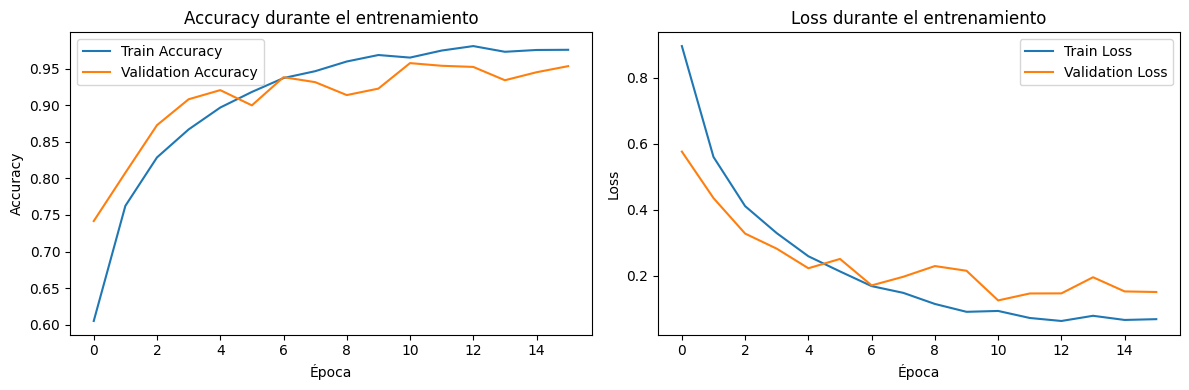

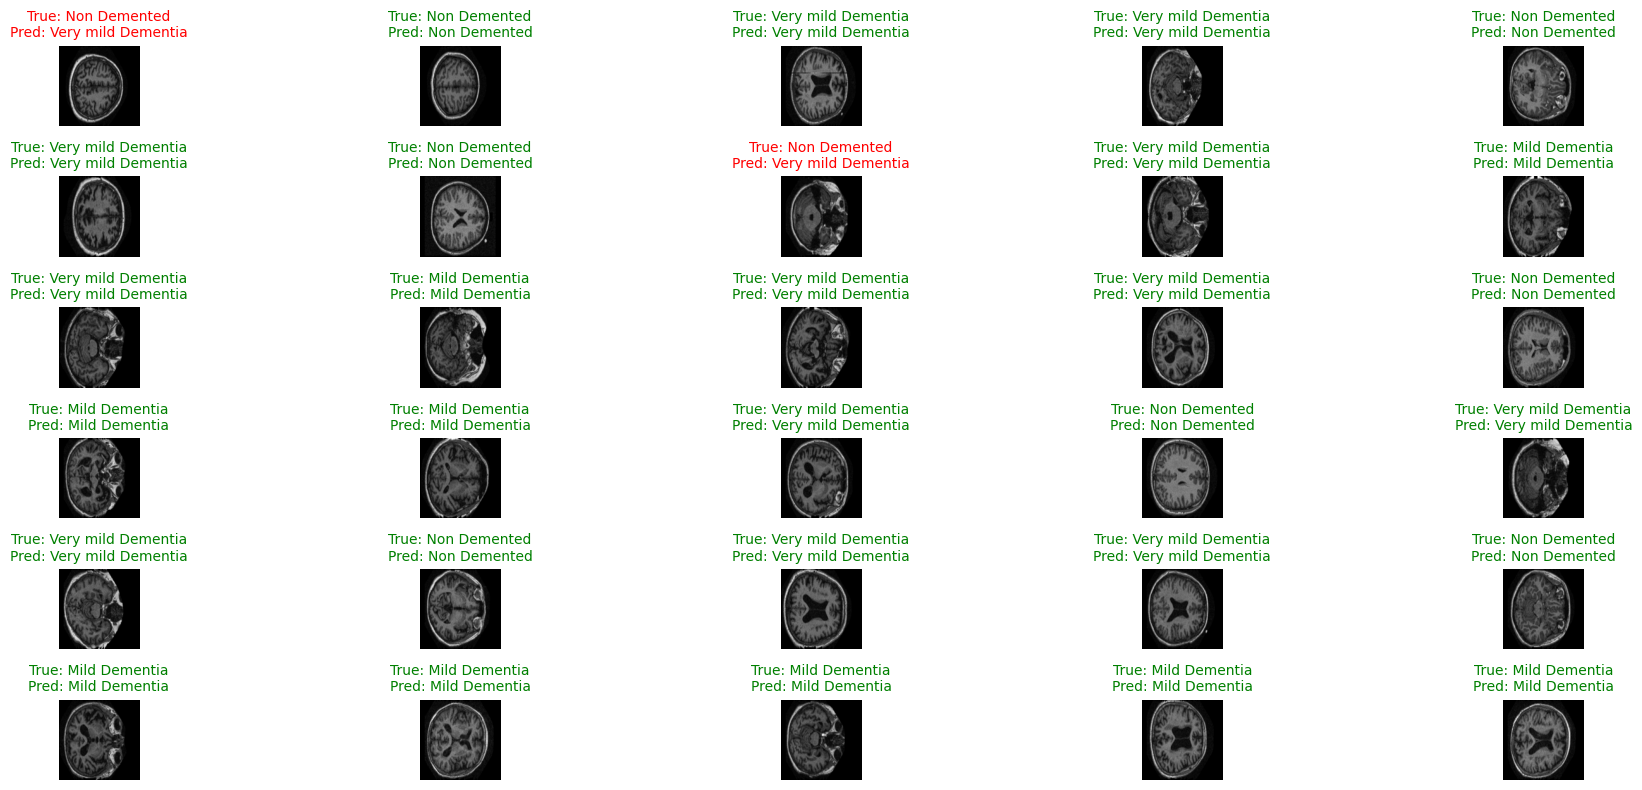

In [20]:
import matplotlib.pyplot as plt
import random
import numpy as np

model = best_model

y_pred_probs = model.predict(X_test_flat)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

correct_idx = np.where(y_pred_classes == y_true_classes)[0]
incorrect_idx = np.where(y_pred_classes != y_true_classes)[0]

print(f"Correct predictions: {len(correct_idx)}")
print(f"Incorrect predictions: {len(incorrect_idx)}")

plt.figure(figsize=(12, 4))

# Mostramos los valores de la precisión y pérdida durante el entrenamiento
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

class_names = ['Non Demented', 'Moderate Dementia', 'Mild Dementia', 'Very mild Dementia']

num_images_to_show = 30
random_indices = random.sample(range(len(X_test)), num_images_to_show)

cols = 5
rows = int(np.ceil(num_images_to_show / cols))

plt.figure(figsize=(20, 8))
for i, idx in enumerate(random_indices):
    img = X_test[idx]
    true_label = y_test[idx]
    true_label = np.argmax(y_test[idx])
    predicted_label = y_pred_classes[idx]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)

    correct = (true_label == predicted_label)
    color = "green" if correct else "red"

    # Por cada imagen mostramos un texto indicando la clase real de la imagen y la predicha
    # Si se ha predicho mal se muestra en rojo el texto, si no en verde
    plt.title(
        f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}",
        fontsize=10,
        color=color
    )
    plt.axis('off')

    # Añadimos bordes a las gráficas para que se vean más bonitas
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig('predicciones_cnn.png', dpi=300, bbox_inches='tight')
plt.show()

Por último obtenemos una imagen del modelo que se va a usar para el informe final

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 896)            │    44,041,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 768)            │       688,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │         3,076 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,199,182 (511.93 MB)

 Trainable params: 44,733,060 (170.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 89,466,122 (341.29 MB)

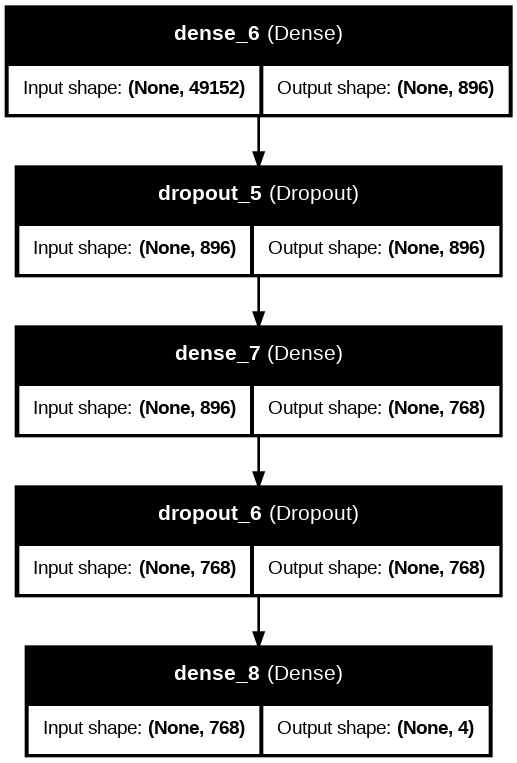

In [24]:
from tensorflow import keras


best_model.summary()

from tensorflow.keras.utils import plot_model
# Se guarda una imagen del modelo para mostrar luego en el informe
plot_model(best_model,
           to_file="/kaggle/working/best_model.png",
           show_shapes=True,
           show_layer_names=True,
           dpi=96)
